# XGBoost (XGB)

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    run_stratified_cv,
    run_seed_sweep, SweepResult,
    print_sweep_classification_report,
    print_sweep_performance_summary,
    print_sweep_error_patterns,
    plot_posterior_violins,
    plot_sweep_f1_bar, plot_sweep_confusion_matrix, plot_sweep_feature_importances,
)

## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

LOG_COLS = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "sy_dist"]
for col in LOG_COLS:
    df[col] = np.log1p(df[col].clip(lower=0))

# No clipping or scaling — tree ensembles split on raw thresholds.
X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(
    df,
    scaler=StandardScaler(),
    smote_variant="standard",
)

class_names, classes, colors = get_class_meta()

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features (train): 343 → 0 nulls
[Tier 5a] st_met: filled 343 via grouped median by spectral type (train)
[Tier 5b] st_age: filled 988 via RF regression + median fallback (train)
[Tier 6] KNN imputer (train): 97 → 0 nulls

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    300
1.0    200
2.0    200
Name: count, dtype: int64
Balanced train shape: (700, 17)
Class weights: {np.int64(0): np.float64(0.7777777777777778), np.int64(1): np.float64(1.1666666666666667), np.int64(2): np.float64(1.1666666666666667)}

Outputs ready for modeling:
  X_train_bal       → (700, 17) (balanced, scaled)
  y_train_bal       → 700 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [3]:
# Stage 1: find n_estimators via early stopping
_X_tr, _X_val, _y_tr, _y_val = train_test_split(
    X_train_bal, y_train_bal, test_size=0.2, stratify=y_train_bal, random_state=42
)

_probe = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=5,
    early_stopping_rounds=50,
    eval_metric="mlogloss",
    random_state=42,
    verbosity=0,
    n_jobs=-1,
)
_probe.fit(_X_tr, _y_tr, eval_set=[(_X_tr, _y_tr), (_X_val, _y_val)], verbose=False)
n_estimators_opt = _probe.best_iteration + 1
print(f"Early stopping: optimal n_estimators = {n_estimators_opt}")

# Stage 2: grid search over structural hyperparams
param_grid = {
    "learning_rate": [0.01, 0.1, 0.3],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
}

grid_xgb = run_grid_search(
    XGBClassifier(
        n_estimators=n_estimators_opt,
        importance_type="gain",
        random_state=42,
        verbosity=0,
        n_jobs=-1,
    ),
    param_grid,
    X_train_bal,
    y_train_bal,
)
xgb = grid_xgb.best_estimator_

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb  = xgb.predict_proba(X_test_scaled)

print(f"Best learning_rate:    {grid_xgb.best_params_['learning_rate']}")
print(f"Best max_depth:        {grid_xgb.best_params_['max_depth']}")
print(f"Best min_child_weight: {grid_xgb.best_params_['min_child_weight']}")
print(f"Best CV F1 Macro:      {grid_xgb.best_score_:.4f}")
print(f"n_estimators:          {xgb.n_estimators}  (early-stopping-optimal)")

Early stopping: optimal n_estimators = 44
Best learning_rate:    0.3
Best max_depth:        5
Best min_child_weight: 3
Best CV F1 Macro:      0.9873
n_estimators:          44  (early-stopping-optimal)


### Seed-Sweep Evaluation

Grid search above tuned hyperparameters on `random_state=42` only, with `n_estimators` fixed at the early-stopping-optimal value from the same split. The single test F1 macro from that one split is a noisy estimate when the minority test classes are tiny (6 mesoplanet, 8 psychroplanet samples). Re-evaluate with the same tuned hyperparameters across 50 random splits to estimate expected performance — and capture per-seed confusion matrices and gain-based feature importances for downstream aggregated diagnostics.

In [4]:
sweep_xgb = run_seed_sweep(
    lambda cw: XGBClassifier(
        **grid_xgb.best_params_,
        n_estimators=n_estimators_opt,     # from cell 5's early-stopping probe
        importance_type="gain",
        random_state=42, n_jobs=-1,
        eval_metric="mlogloss", verbosity=0,
    ),
    df,
    n_seeds=50,
    model_name="XGB",
    save_csv="sweep_xgb.csv",
    save_pickle="sweep_xgb.pkl",
)

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/si

XGB — 50-seed sweep
  F1 macro:    0.7512 ± 0.0509  (SEM 0.0072, min 0.6429, max 0.8975)
  F1 weighted: 0.9882 ± 0.0028
  Captured feature importances for 50 seeds.
  F1 DataFrame saved to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/advanced_models/../data/output/seed_sweep_results/sweep_xgb.csv
  Full SweepResult pickled to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/advanced_models/../data/output/seed_sweep_results/sweep_xgb.pkl


## Modeling
### DIAGNOSTIC PLOT 1: Feature Importances (Gain)

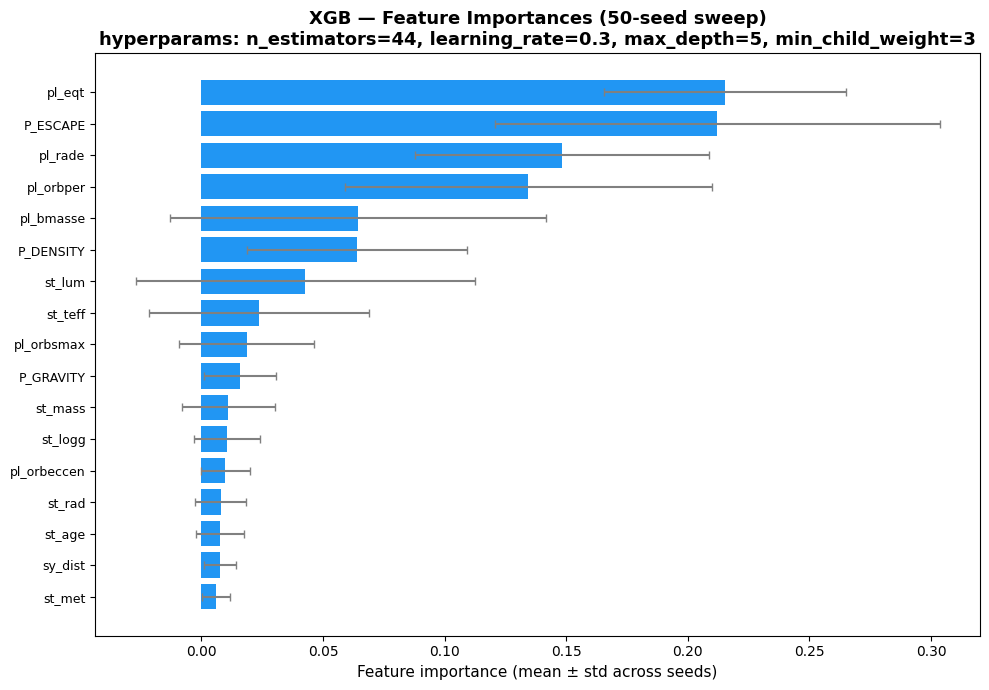

In [5]:
plot_sweep_feature_importances(
    sweep_xgb,
    subtitle=f"hyperparams: n_estimators={n_estimators_opt}, "
             f"learning_rate={grid_xgb.best_params_['learning_rate']}, "
             f"max_depth={grid_xgb.best_params_['max_depth']}, "
             f"min_child_weight={grid_xgb.best_params_['min_child_weight']}",
)

### DIAGNOSTIC PLOT 2: Learning Rate vs CV F1 Macro

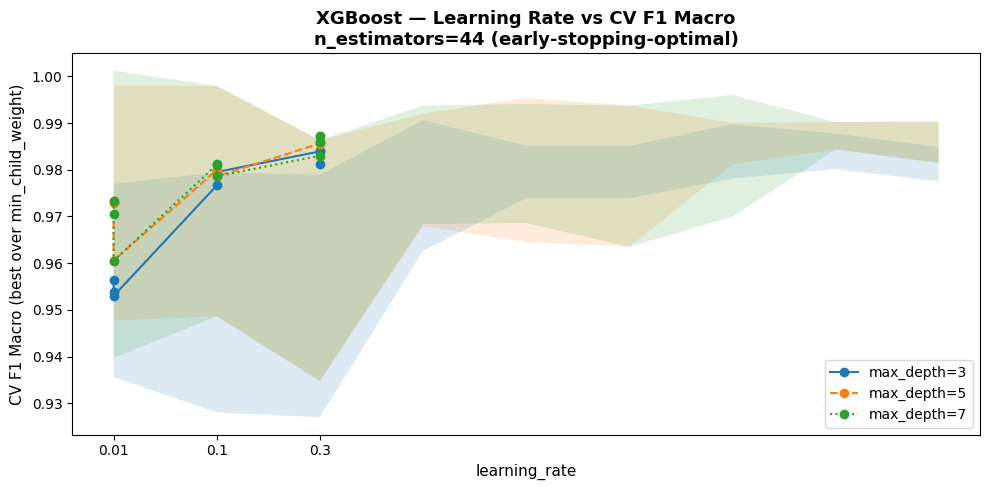

↑ Low learning_rate = smaller steps, needs more trees to converge (n_estimators already fixed).
  Shallow trees (max_depth=3) with low learning_rate = classic conservative boosting setup.
  Shaded band = ±1 std across CV folds.


In [6]:
results_df = pd.DataFrame(grid_xgb.cv_results_)

fig, ax = plt.subplots(figsize=(10, 5))
for depth, ls in [(3, "-"), (5, "--"), (7, ":")]:
    sub = results_df[results_df["param_max_depth"] == depth].sort_values("param_learning_rate")
    ax.plot(sub["param_learning_rate"].astype(str), sub["mean_test_score"],
            marker="o", ls=ls, label=f"max_depth={depth}")
    ax.fill_between(
        range(len(sub)),
        sub["mean_test_score"] - sub["std_test_score"],
        sub["mean_test_score"] + sub["std_test_score"],
        alpha=0.15,
    )

ax.set_xlabel("learning_rate", fontsize=11)
ax.set_ylabel("CV F1 Macro (best over min_child_weight)", fontsize=11)
ax.set_title(
    f"XGBoost — Learning Rate vs CV F1 Macro\n"
    f"n_estimators={xgb.n_estimators} (early-stopping-optimal)",
    fontsize=13, fontweight="bold",
)
ax.legend(fontsize=10)
plt.tight_layout()
save_plot("xgb_learning_rate_sensitivity")
plt.show()

print("↑ Low learning_rate = smaller steps, needs more trees to converge (n_estimators already fixed).")
print("  Shallow trees (max_depth=3) with low learning_rate = classic conservative boosting setup.")
print("  Shaded band = ±1 std across CV folds.")

### DIAGNOSTIC PLOT 3: Early Stopping Convergence

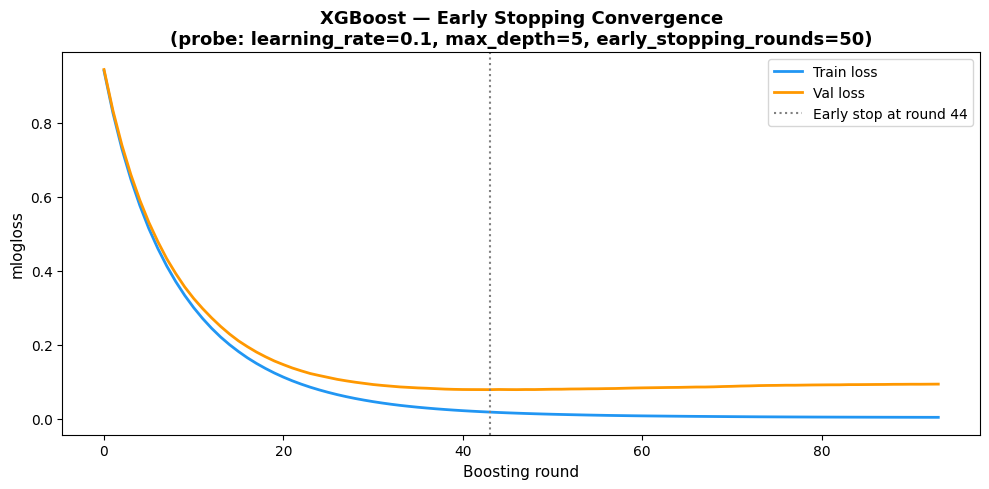

↑ Training stops when validation loss fails to improve for 50 consecutive rounds.
  Gap between train and val loss = overfitting — wider gap means the model memorised the training set.
  This is analogous to RF's OOB convergence: both find the point of diminishing returns.


In [7]:
_evals = _probe.evals_result()
_train_loss = _evals["validation_0"]["mlogloss"]
_val_loss   = _evals["validation_1"]["mlogloss"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(_train_loss, color="#2196F3", lw=2, label="Train loss")
ax.plot(_val_loss,   color="#FF9800", lw=2, label="Val loss")
ax.axvline(n_estimators_opt - 1, color="gray", ls=":", lw=1.5,
           label=f"Early stop at round {n_estimators_opt}")
ax.set_xlabel("Boosting round", fontsize=11)
ax.set_ylabel("mlogloss", fontsize=11)
ax.set_title(
    f"XGBoost — Early Stopping Convergence\n"
    f"(probe: learning_rate=0.1, max_depth=5, early_stopping_rounds=50)",
    fontsize=13, fontweight="bold",
)
ax.legend(fontsize=10)
plt.tight_layout()
save_plot("xgb_early_stopping")
plt.show()

print("↑ Training stops when validation loss fails to improve for 50 consecutive rounds.")
print("  Gap between train and val loss = overfitting — wider gap means the model memorised the training set.")
print("  This is analogous to RF's OOB convergence: both find the point of diminishing returns.")

## Metrics
### Classification Report + F1 Scores

XGB — Classification Report (50-seed sweep)
Class               F1 mean     F1 std     F1 min     F1 max
----------------------------------------------------------------
Non-Habitable        0.9929     0.0021     0.9876     0.9968
Mesoplanet           0.7300     0.1106     0.5556     1.0000
Psychroplanet        0.5308     0.0974     0.3529     0.8000
----------------------------------------------------------------
Macro avg            0.7512     0.0509     0.6429     0.8975
Weighted avg         0.9882     0.0028     0.9809     0.9947

5-Fold CV F1 Macro: 0.9826 ± 0.0098

XGB — Performance Summary (50-seed sweep)

Per-class Precision and Recall (mean ± std)
                 Precision            Recall              
Non-Habitable    0.9995 ± 0.0006    0.9864 ± 0.0040
Mesoplanet       0.6290 ± 0.1504    0.9133 ± 0.1357
Psychroplanet    0.3852 ± 0.0941    0.8850 ± 0.1125
----------------------------------------------------------------
Macro avg        0.6712 ± 0.0585    0.9283 ± 0.0545
Wei

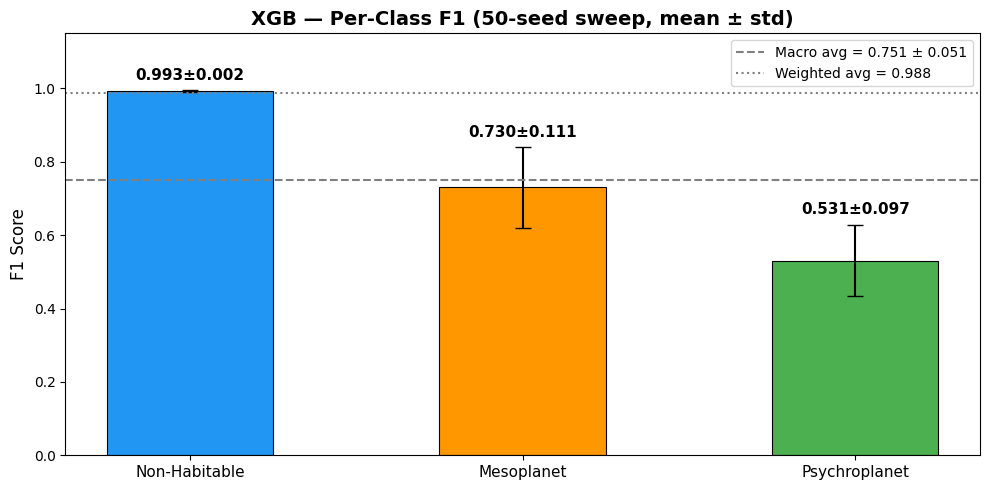

In [8]:
# Per-class F1 with mean ± std from the seed sweep
print_sweep_classification_report(sweep_xgb)

# 5-fold CV on the balanced training set — orthogonal to sweep variance,
# measures within-seed tuning stability (different question).
cv_scores_xgb = run_stratified_cv(xgb, X_train_bal, y_train_bal)

# Cross-model comparison metrics: per-class P/R + aggregate robustness scores
# (MCC, balanced accuracy, minority F1 macro)
print_sweep_performance_summary(sweep_xgb)

# Per-class bar chart with error bars from the sweep distribution
plot_sweep_f1_bar(sweep_xgb)

### Confusion Matrices (Counts + Normalized)

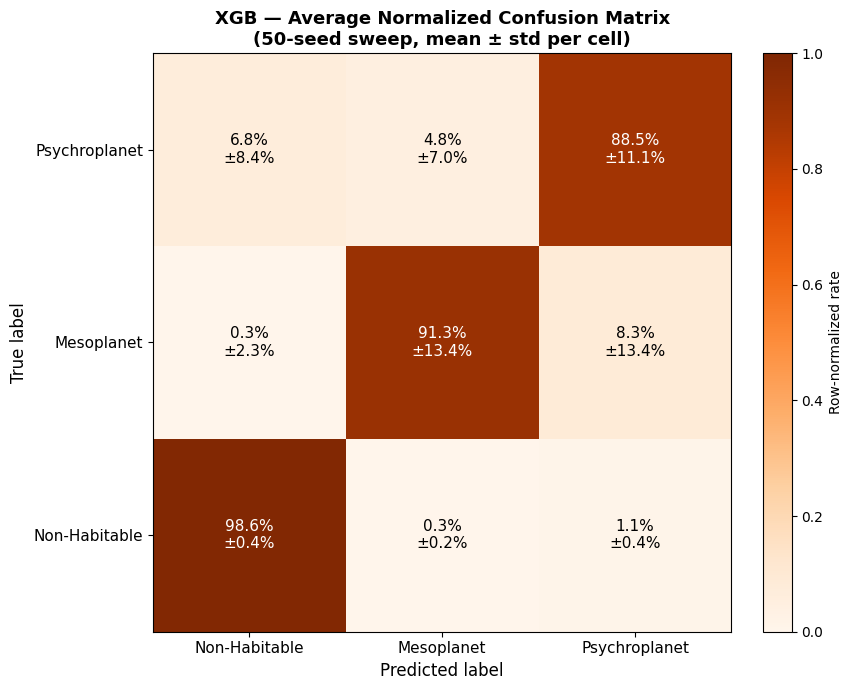

Key error patterns (50-seed sweep):
  Non-Habitable → predicted Mesoplanet: 3.30 ± 1.90 per split  (0.3% ± 0.2% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 11.64 ± 4.08 per split  (1.1% ± 0.4% of true Non-Habitable)
  Mesoplanet → predicted Non-Habitable: 0.02 ± 0.14 per split  (0.3% ± 2.3% of true Mesoplanet)
  Mesoplanet → predicted Psychroplanet: 0.50 ± 0.81 per split  (8.3% ± 13.4% of true Mesoplanet)
  Psychroplanet → predicted Non-Habitable: 0.54 ± 0.67 per split  (6.8% ± 8.4% of true Psychroplanet)
  Psychroplanet → predicted Mesoplanet: 0.38 ± 0.56 per split  (4.8% ± 7.0% of true Psychroplanet)


In [9]:
# Average row-normalized CM across all 50 seeds, annotated per-cell with std
plot_sweep_confusion_matrix(sweep_xgb)

# Off-diagonal patterns: per-split count and per-class rate, both mean ± std
print_sweep_error_patterns(sweep_xgb)

## Interpretation: